In [1]:
import sys
import os
import json

sys.path.append(os.path.abspath(".."))

import torch
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from torch.utils.data import DataLoader

from src.dataset import DiarioDataset
from src.model import DiarioClassifier

In [13]:
df = pd.read_csv("../data/processed/amostra_rotulada.csv")

with open("../data/processed/vocab.json","r",encoding="utf8") as f:
    vocab = json.load(f)

with open("../data/processed/label_map.json","r",encoding="utf8") as f:
    label_map = json.load(f)

print(df.head())
print(label_map)
print(f"Total de documentos: {len(df)}")

print(f"\nTotal de documentos: {len(df)}")
print(f"Tamanho do vocabulário: {len(vocab)}")
print(f"Classes: {list(label_map.keys())}")

   id                   texto     classe
0   1    Nomeação de servidor         RH
1   2  Contratação de empresa  Licitacao
2   3       Decreto municipal    Decreto
3   4    Nomeação de servidor         RH
4   5  Contratação de empresa  Licitacao
{'Decreto': 0, 'Licitacao': 1, 'RH': 2}
Total de documentos: 40

Total de documentos: 40
Tamanho do vocabulário: 8
Classes: ['Decreto', 'Licitacao', 'RH']


In [14]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df["classe"]
)

In [15]:
train_dataset = DiarioDataset(train_df, vocab, label_map)

test_dataset = DiarioDataset(test_df, vocab, label_map)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16
)

In [16]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

modelo = DiarioClassifier(
    vocab_size=len(vocab),
    num_classes=len(label_map)
)

modelo.to(device)

DiarioClassifier(
  (embedding): Embedding(8, 128, padding_idx=0)
  (fc1): Linear(in_features=128, out_features=128, bias=True)
  (relu): ReLU()
  (dropout): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=3, bias=True)
)

In [17]:
criterion = torch.nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    modelo.parameters(),
    lr=0.001
)

In [18]:
losses = []

for epoca in range(20):

    modelo.train()

    loss_total = 0

    for textos, classes in train_loader:

        textos = textos.to(device)
        classes = classes.to(device)

        optimizer.zero_grad()

        saida = modelo(textos)

        loss = criterion(saida, classes)

        loss.backward()

        optimizer.step()

        loss_total += loss.item()

    media = loss_total / len(train_loader)

    losses.append(media)

    print(f"Época {epoca+1}/20 - Loss: {media:.4f}")

Época 1/20 - Loss: 0.9801
Época 2/20 - Loss: 0.6918
Época 3/20 - Loss: 0.5642
Época 4/20 - Loss: 0.4145
Época 5/20 - Loss: 0.3345
Época 6/20 - Loss: 0.2123
Época 7/20 - Loss: 0.1623
Época 8/20 - Loss: 0.1359
Época 9/20 - Loss: 0.0972
Época 10/20 - Loss: 0.0772
Época 11/20 - Loss: 0.0592
Época 12/20 - Loss: 0.0373
Época 13/20 - Loss: 0.0316
Época 14/20 - Loss: 0.0231
Época 15/20 - Loss: 0.0226
Época 16/20 - Loss: 0.0194
Época 17/20 - Loss: 0.0153
Época 18/20 - Loss: 0.0126
Época 19/20 - Loss: 0.0144
Época 20/20 - Loss: 0.0094


In [19]:
torch.save(
    modelo.state_dict(),
    "../models/modelo.pt"
)

print("Modelo salvo!")

Modelo salvo!


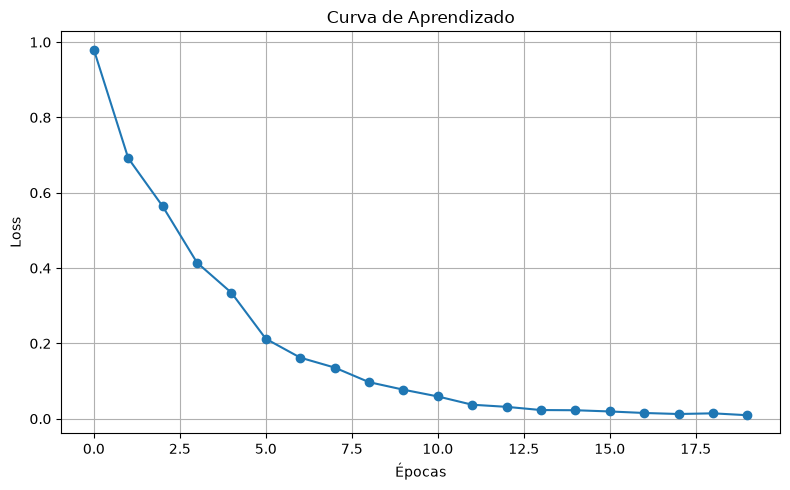

In [20]:
plt.figure(figsize=(8,5))

plt.plot(losses, marker="o")

plt.title("Curva de Aprendizado")

plt.xlabel("Épocas")

plt.ylabel("Loss")

plt.grid()

plt.tight_layout()

plt.savefig("../docs/curva_aprendizado.png")

plt.show()

In [21]:
modelo.eval()

predicoes = []

reais = []

with torch.no_grad():

    for textos, classes in test_loader:

        textos = textos.to(device)

        saida = modelo(textos)

        pred = saida.argmax(1).cpu().numpy()

        predicoes.extend(pred)

        reais.extend(classes.numpy())

In [22]:
acc = accuracy_score(reais,predicoes)

print("Acurácia:",acc)

print()

print(
    classification_report(
        reais,
        predicoes,
        target_names=list(label_map.keys())
    )
)

Acurácia: 1.0

              precision    recall  f1-score   support

     Decreto       1.00      1.00      1.00         3
   Licitacao       1.00      1.00      1.00         2
          RH       1.00      1.00      1.00         3

    accuracy                           1.00         8
   macro avg       1.00      1.00      1.00         8
weighted avg       1.00      1.00      1.00         8



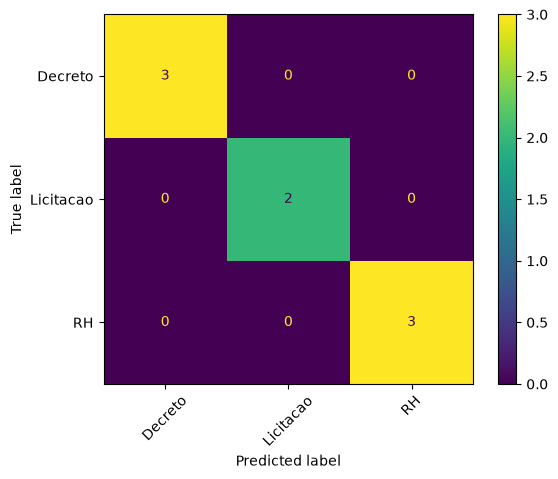

In [23]:
cm = confusion_matrix(reais,predicoes)

disp = ConfusionMatrixDisplay(
    cm,
    display_labels=list(label_map.keys())
)

disp.plot(
    xticks_rotation=45
)

plt.show()